Possibly nothing useful here.


In [1]:
%%time
import numpy as np
import matplotlib.pyplot as plt
import sys
import math
import pandas as pd
import numpy as np

CPU times: user 1.38 s, sys: 1.39 s, total: 2.77 s
Wall time: 815 ms


In [2]:
import xarray as xr
ds = xr.open_dataset("../data/data_stream-oper_stepType-instant.nc", engine='h5netcdf')

lat = ds['latitude'].values
lon = ds['longitude'].values

# Coordinates of interest
lat_point = 45.6667
lon_point = -119.6667

# Find the closest indices
lat_idx = (np.abs(lat - lat_point)).argmin() + 1
lon_idx = (np.abs(lon - lon_point)).argmin() + 1

# Extract data at the closest point
data_at_point = ds.isel(latitude=lat_idx, longitude=lon_idx)


In [3]:
# Project imports
from sutton import (
    Params,
    thomas,
    our_central_difference,
    integrate_T_implicit,
    integrate_H2O_implicit,
    stability,
    saturation_vapor_pressure,
    vapor_concentration_RH,
)

In [4]:
def get_lm(k, h, z, option = 'kz'):
    """
    mixing length options
    """
    d = 2/3*h
    
    if option == 'kz':
        lm = k*z
    else:
        a = 1
        lm = k*z   
        lm[z < a*(h - d)] = k*a*h/3 
  
    return lm


### Boundary conditions from Rao et al (1974)

In [5]:
sigma_sb = 5.670374419e-8  # W m^-2 K^-4

cp_air  = 1005.0     # J kg^-1 K^-1
rho_air = 1.20       # kg m^-3

Lv      = 2.43e6     # J kg^-1
Lv_g    = 2430.0  # J g^-1  (~30 °C)


# Convert to SI units (W/m²)
SH_f = 350             # (W/m²)
LE_f = 100


# Upwind desert (dry) – prescribed flux BCs
H_f  = 350.0      # W m^-2
LE_f = 100.0      # W m^-2

# Downwind irrigated field (wet) – available energy; LE/H computed by your model
Rn_minus_G = 550   # W m^-2, i.e., R_n - G over the crop field


H_c  = 53.0      # W m^-2  (tower A mean)
LE_c = 494.0     # W m^-2  (tower A mean)



# Q_f = 6.34 # g mm3, E_01
# RH_c = 60 # relative humidity
# ustar_f = 0.14

# # immediately downwind of transition
# H_c0 = - 0.6 * rho_air * cp_air
# LE_c0 = rho_air * cp_air

# H_c2 = - 0.2 * rho_air * cp_air
# LE_c2 = 0.44*rho_air * cp_air

# H_c20 = - 0.04 * rho_air * cp_air
# LE_c20 = 0.36*rho_air * cp_air

# # This is approximately 1.2*H_f (read off figure 4)
# Rn_minus_G = - 0.355 * rho_air * cp_air

In [6]:
# --- study means / forcing (near-neutral) ---
U_ref     = 3.76    # m s^-1  (used by resolve_ustars, z_ref_wind = 4 m in your Params)
ustar_ref = 0.378   # m s^-1  (optional if you want to pin u*)


In [7]:
# --- physical constants (unchanged) ---
sigma_sb = 5.670374419e-8  # W m^-2 K^-4
cp_air   = 1005.0          # J kg^-1 K^-1
rho_air  = 1.20            # kg m^-3

Lv       = 2.43e6          # J kg^-1




In [8]:

from dataclasses import dataclass, asdict
from typing import Optional
import numpy as np
from functools import cached_property
from sutton import saturation_vapor_pressure, vapor_concentration_RH
import sympy as sp



@dataclass
class Params:
    # --- core physics/numerics  ---
    k: float = 0.4
    zom_f: float = 0.005           # m (wet/downwind momentum roughness)
    zom_c: float = 0.05            # m (dry/upwind momentum roughness)

    # canopy & displacement inputs (per patch)
    # (If None → derive from z0m via alpha_m, disp_frac; see properties below)
    h_f_opt: Optional[float] = None
    h_c_opt: Optional[float] = None
    d_f_opt: Optional[float] = None
    d_c_opt: Optional[float] = None
    alpha_m: float = 0.10          # z0m ≈ alpha_m * h
    disp_frac: float = 0.67        # d ≈ disp_frac * h
    
    G : float = 0
    # domain/grid
    Lx: float = 100.0               # m
    Hmax: float = 10.0              # m
    dz: float = 0.1                 # m
    dx: float = 1                   # m
    xmin: float = 0.0               # m

    # friction velocities (optional; None ⇒ compute later or via resolve_ustars)
    ustar_f: Optional[float] = 0.15
    ustar_c: Optional[float] = 0.15

    # block pattern
    fallow_fraction: float = 0.5
    fallow_length: float = 1000.0  # m

    # temperatures in °C; RH in %
    T_sc: float = 30.0
    T_sf: float = 50.0
    T_a:  float = 30.0
    RH_c: float = 60
        
    Q_a: float = 6.3
    Q_f: float = 6.3

    # radiation inputs 
    SW_in: float = 400.0
    epsilon_f: float = 0.90
    epsilon_c: float = 0.95
    epsilon_a: float = 0.80
    alpha_c: float = 0.22
    alpha_f: float = 0.22

    lm_option: str | None = "kz"

    # reference wind for u* inference (if you compute from log law)
    U_ref: float = 3.76            # m s^-1 at z_ref_wind
    z_ref_wind: float = 4.0        # m

    # Upstream/base flux: Rao base case uses (RN-G)_up = H_f
    H_f: float = 8.5*4.184e-3/1e-4   # ≈ 356 W m^-2
    LE_f: float = 0.0                # upstream LE 
    
    # avail_ratio 1: downstream available energy & partition 
    avail_ratio: float = 1   # (RN-G)_down / (RN-G)_up, dimensionless
    le_factor: float = 1.0             # 0..1: downstream LE_c = le_factor * avail_ratio

    # ----------------- helpers & grids -----------------
    @staticmethod
    def _K(Tc: float) -> float:
        return Tc + 273.15

    # derived canopy height & displacement (per patch)
    @cached_property
    def h_f(self) -> float:
        if self.h_f_opt is not None: return float(self.h_f_opt)
        if self.d_f_opt is not None: return float(self.d_f_opt) / self.disp_frac
        return float(self.zom_f) / self.alpha_m

    @cached_property
    def h_c(self) -> float:
        if self.h_c_opt is not None: return float(self.h_c_opt)
        if self.d_c_opt is not None: return float(self.d_c_opt) / self.disp_frac
        return float(self.zom_c) / self.alpha_m

    @cached_property
    def d_f(self) -> float:
        if self.d_f_opt is not None: return float(self.d_f_opt)
        if self.h_f_opt is not None: return self.disp_frac * float(self.h_f_opt)
        return self.disp_frac * (float(self.zom_f) / self.alpha_m)

    @cached_property
    def d_c(self) -> float:
        if self.d_c_opt is not None: return float(self.d_c_opt)
        if self.h_c_opt is not None: return self.disp_frac * float(self.h_c_opt)
        return self.disp_frac * (float(self.zom_c) / self.alpha_m)

    #  zmin respects (z - d) > z0 → keep grid valid for both patches
    @cached_property
    def zmin(self) -> float:
        thresh_f = self.d_f + self.zom_f
        thresh_c = self.d_c + self.zom_c
        return max(thresh_f, thresh_c)   # conservative global lower bound

    @cached_property
    def z(self) -> np.ndarray:
        return np.arange(self.zmin + self.dz, self.Hmax + self.dz, self.dz)

    @cached_property
    def x(self) -> np.ndarray:
        return np.arange(self.xmin, self.Lx + self.dx, self.dx)

    @property
    def nz(self) -> int: return len(self.z)

    @property
    def nx(self) -> int: return len(self.x)

    # u* optional compute (unchanged)
    def resolve_ustars(self):
        if self.ustar_f is None:
            assert self.z_ref_wind > self.zom_f > 0
            self.ustar_f = self.k * self.U_ref / np.log(self.z_ref_wind / self.zom_f)
        if self.ustar_c is None:
            assert self.z_ref_wind > self.zom_c > 0
            self.ustar_c = self.k * self.U_ref / np.log(self.z_ref_wind / self.zom_c)
        return self

    # block sizes (fixed ternary line break)
    @cached_property
    def fallow_size(self) -> int:
        return int(self.fallow_length / self.dx)

    @cached_property
    def field_size(self) -> int:
        return (
            int(self.fallow_size * (1 - self.fallow_fraction) / self.fallow_fraction)
            if self.fallow_fraction > 0 else 0
        )
    
    @cached_property
    def lm(self):

        d = 2/3*self.h_c
        z = self.z
        k = self.k
        h = self.h_c
        
        if self.lm_option == 'kz':
            lm = k*z
        else:
            a = 1
            lm = k*z   
            lm[z < a*(h - d)] = k*a*h/3 

        return lm


    # Saturation vapor pressure over liquid water (Pa) via Clausius–Clapeyron
    @cached_property
    def es_c(self) -> float:
        return saturation_vapor_pressure(self._K(self.T_sc))

    @cached_property
    def es_f(self) -> float:
        return saturation_vapor_pressure(self._K(self.T_sf))

    # humidity as absolute humidity (your Q_* names retained)    
    @cached_property
    def Q_c(self) -> float:
        return vapor_concentration_RH(self.T_sc, self.RH_c)
    
    # energy partition
    
    #  upstream available energy  
    @property
    def RNmG_up(self) -> float:
        return self.H_f

    @property
    def RNmG_down(self) -> float:
        """Downstream available energy = avail_ratio * RNmG_up (W m^-2)."""
        return self.RNmG_up * self.avail_ratio    

    # downstream partition 
    @property
    def LE_c(self) -> float:
        lf = min(max(self.le_factor, 0.0), 1.0)
        return lf * self.RNmG_up * self.avail_ratio

    @property
    def H_c(self) -> float:
        lf = min(max(self.le_factor, 0.0), 1.0)
        return (1.0 - lf) * self.RNmG_up * self.avail_ratio

    # optional dict for legacy call sites
    def to_dict(self) -> dict:
        d = asdict(self)
        d.update({
            "x": self.x, "z": self.z, "nx": self.nx, "nz": self.nz,
            "zmin": self.zmin, "zmax": self.Hmax, "xmax": self.Lx,
            "ustar_f": self.ustar_f, "ustar_c": self.ustar_c,
            "fallow_size": self.fallow_size, "field_size": self.field_size,
            "Q_c": self.Q_c, "Q_f": self.Q_f, "Q_a": self.Q_a,
            "es_c": self.es_c, "es_f": self.es_f,
            # partition values
            "LE_c": self.LE_c, 
            "H_c": self.H_c,
            "RNmG_up": self.RNmG_up, 
            "RNmG_down": self.RNmG_down,
            # canopy/displacement (derived)
            "h_f": self.h_f, "h_c": self.h_c, 
            "d_f": self.d_f, "d_c": self.d_c,
        })
        return d


    def solve_surface_radiation_inplace(self, *, fix: str = "alpha_f") -> dict:
        """
        Solve the two-surface net-radiation balances using ONLY internal Params state,
        then update Params in place (SW_in and the free albedo).

          Rn_f = SW*(1 - alpha_f) + eps_a*sigma*T_a^4 - eps_f*sigma*T_sf^4
          Rn_c = SW*(1 - alpha_c) + eps_a*sigma*T_a^4 - eps_c*sigma*T_sc^4

        Rn_f = RNmG_up + G;  Rn_c = RNmG_down + G

        Args
        ----
        fix : {"alpha_f","alpha_c"}
            Which albedo to treat as fixed (kept from Params). The other is solved.

        Returns
        -------
        dict with {"SW": float, "alpha_f": float, "alpha_c": float, "Rn_f": float, "Rn_c": float}
        """
        if fix not in ("alpha_f", "alpha_c"):
            raise ValueError("fix must be 'alpha_f' or 'alpha_c'.")

        # Upstream/downstream net radiation from internal partition + ground flux
        Rn_f = float(self.RNmG_up + self.G)
        Rn_c = float(self.RNmG_down + self.G)

        # Temps (°C -> K)
        TaK  = self._K(self.T_a)
        TsfK = self._K(self.T_sf)
        TscK = self._K(self.T_sc)

        # Symbols and constants
        SW = sp.symbols('SW', real=True)
        sigma = sigma_sb
        ea, ef, ec = self.epsilon_a, self.epsilon_f, self.epsilon_c

        if fix == "alpha_f":
            # Unknowns: SW, alpha_c  (alpha_f fixed from Params)
            alpha_c_sym = sp.symbols('alpha_c', real=True)
            eq1 = sp.Eq(SW*(1 - self.alpha_f) + ea*sigma*TaK**4 - ef*sigma*TsfK**4, Rn_f)
            eq2 = sp.Eq(SW*(1 - alpha_c_sym) + ea*sigma*TaK**4 - ec*sigma*TscK**4, Rn_c)
            sol = sp.solve((eq1, eq2), (SW, alpha_c_sym), dict=True)
            if not sol:
                raise RuntimeError("No solution for (SW, alpha_c). Check inputs.")
            SW_val      = float(sol[0][SW])
            alpha_c_val = float(sol[0][alpha_c_sym])

            # Clip to physical range [0,1] with a gentle nudge/warn if needed
            alpha_c_val = min(max(alpha_c_val, 0.0), 1.0)

            # update params in place
            self.SW_in  = SW_val
            self.alpha_c = alpha_c_val

            return {"SW": SW_val, "alpha_f": float(self.alpha_f), "alpha_c": alpha_c_val,
                    "Rn_f": Rn_f, "Rn_c": Rn_c}

        else:
            # fix == "alpha_c": Unknowns: SW, alpha_f  (alpha_c fixed from Params)
            alpha_f_sym = sp.symbols('alpha_f', real=True)
            eq1 = sp.Eq(SW*(1 - alpha_f_sym) + ea*sigma*TaK**4 - ef*sigma*TsfK**4, Rn_f)
            eq2 = sp.Eq(SW*(1 - self.alpha_c) + ea*sigma*TaK**4 - ec*sigma*TscK**4, Rn_c)
            sol = sp.solve((eq1, eq2), (SW, alpha_f_sym), dict=True)
            if not sol:
                raise RuntimeError("No solution for (SW, alpha_f). Check inputs.")
            SW_val      = float(sol[0][SW])
            alpha_f_val = float(sol[0][alpha_f_sym])

            alpha_f_val = min(max(alpha_f_val, 0.0), 1.0)

            # update params in place
            self.SW_in   = SW_val
            self.alpha_f = alpha_f_val

            return {"SW": SW_val, "alpha_f": alpha_f_val, "alpha_c": float(self.alpha_c),
                    "Rn_f": Rn_f, "Rn_c": Rn_c}


    def update_surface_BCs_from_reference(self) -> dict:
        """
        Update both wall BCs (T_sc, T_sf, Q_c, Q_f) assuming the reference air
        state (T_a, Q_a) is at z_ref = p.z[0]. Neutral two-point form:
          T_s = T_a + (H/(rho*cp*u_* * k)) * ln(z_h / z_ref)
          Q_s = Q_a + (1000*LE/(lv*u_* * k)) * ln(z_h / z_ref)   [Q in g m^-3]
        """
        z_h   = float(self.Hmax)
        z_ref = float(self.z[0])

        kappa = float(self.k)

        log_frac = np.log(z_h / z_ref)

        # dry (c)
        T_sc_new = self.T_a + (self.H_c  / (rho_air*cp_air*self.ustar_c*kappa)) * log_frac
        Q_c_new  = self.Q_a + (self.LE_c / (Lv_g*self.ustar_c*kappa)) * log_frac
        self.T_sc = float(T_sc_new)
        for name in ("es_c","Q_c"): self.__dict__.pop(name, None)
        self.__dict__["Q_c"] = float(Q_c_new)

        # wet (f)
        T_sf_new = self.T_a + (self.H_f  / (rho_air*cp_air*self.ustar_f*kappa)) * log_frac
        Q_f_new  = self.Q_a + (self.LE_f / (Lv_g*self.ustar_f*kappa)) * log_frac
        self.T_sf = float(T_sf_new)
        for name in ("es_f","Q_f"): self.__dict__.pop(name, None)
        self.__dict__["Q_f"] = float(Q_f_new)

        return {"z_ref": z_ref, "T_sc": self.T_sc, "T_sf": self.T_sf,
                "Q_c": float(Q_c_new), "Q_f": float(Q_f_new)}


    def update_surface_BCs_from_zom(self) -> dict:
        """
        Update both wall BCs (T_sc, T_sf, Q_c, Q_f) assuming the reference air
        state (T_a, Q_a) is at z = zmax (self.Hmax). Uses neutral log relations:

          T_s = T_a + (H / (rho cp u* k)) * ln(zmax / z0h)
          Q_s = Q_a + (1000 * LE / (lv u* k)) * ln(zmax / z0q)   [Q in g m^-3]
        """
        zmax  = float(self.Hmax)
        kappa = float(self.k)

        if self.ustar_c is None or self.ustar_f is None:
            raise ValueError("ustar_f/ustar_c is None. set them or call resolve_ustars().")

        # if you have dedicated scalar roughness lengths, use z0h/z0q; else use z0m
        z0h_c = self.zom_c
        z0h_f = self.zom_f
        z0q_c = self.zom_c
        z0q_f = self.zom_f

        # ---- dry (c) ----
        T_sc_new = self.T_a + (self.H_c / (rho_air * cp_air * self.ustar_c * kappa)) * np.log(zmax / z0h_c)
        Q_c_new  = self.Q_a + (1000.0 * self.LE_c / (lv * self.ustar_c * kappa)) * np.log(zmax / z0q_c)

        self.T_sc = float(T_sc_new)
        for name in ("es_c", "Q_c"):
            self.__dict__.pop(name, None)
        self.__dict__["Q_c"] = float(Q_c_new)

        # ---- wet (f) ----
        T_sf_new = self.T_a + (self.H_f / (rho_air * cp_air * self.ustar_f * kappa)) * np.log(zmax / z0h_f)
        Q_f_new  = self.Q_a + (1000.0 * self.LE_f / (lv * self.ustar_f * kappa)) * np.log(zmax / z0q_f)

        self.T_sf = float(T_sf_new)
        for name in ("es_f", "Q_f"):
            self.__dict__.pop(name, None)
        self.__dict__["Q_f"] = float(Q_f_new)

        return {"z_ref": zmax, "T_sc": self.T_sc, "T_sf": self.T_sf, "Q_c": float(Q_c_new), "Q_f": float(Q_f_new)}



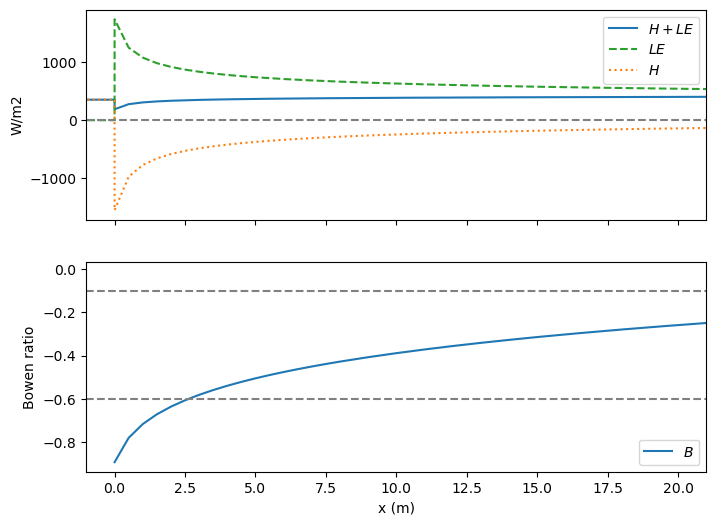

In [9]:

def no_central_difference(s, z):
    """
    Central differences; forward/backward at edges.
    """
    m = len(z)
    dz = np.ones(m)
    ds = np.ones(m)
    dz[:-1] = np.log(z[1:] / z[: -1])
    
    ds[:-1] = (s[1:] - s[: -1])    
    ds_dz = ds/dz
    ds_dz[-1] = ds_dz[-2]
    
    return ds_dz

def integrate_H2O_implicit(p, Q_up, A, B, C):
    """
    One x-step implicit solve for absolute humidity Q (g m^-3).
    BCs: surface Q = p.Q_c, aloft Q = p.Q_a.
    A, B, C : arrays length nz
    """
    
    m   = int(p.nz)
    dx  = p.dx
    dz  = p.dz
    z = p.z
    
    AA1 = -A * B
    AA2 = -C * B
    AA3 = 1 / dx
    AA4 = Q_up / dx

    upd = (AA1 / (dz ** 2) + AA2 / (2 * dz))
    dia = (-2 * AA1 / (dz ** 2) + AA3)
    lod = (AA1 / (dz ** 2) - AA2 / (2 * dz))

    co = np.zeros(m)
    co[:] = AA4

    lod[0] = lod[m - 1] = 0
    dia[0] = dia[m - 1] = 1
    upd[0] = upd[m - 1] = 0

    co[0] = p.Q_c
    co[m - 1] = p.Q_a

    Q1 = thomas(lod, dia, upd, co)
    dQdz = no_central_difference(Q1, z)

    Fq = - A/z *  dQdz
    return Q1, Fq

    
def integrate_T_implicit(p, T_up, A, B, C):
    """
    One x-step implicit solve for temperature T (°C).
    BCs: surface T = p.T_sc, aloft T = p.T_a.
    """
    m   = int(p.nz)
    dx  = p.dx
    dz  = p.dz
    z   = p.z
    
    AA1 = - A * B
    AA2 = - C * B
    AA3 = 1 / dx
    AA4 = T_up / dx

    upd = (AA1 / (dz ** 2) + AA2 / (2 * dz))
    dia = (-2 * AA1 / (dz ** 2) + AA3)
    lod = (AA1 / (dz ** 2) - AA2 / (2 * dz))

    co = np.zeros(m)
    co[:] = AA4

    lod[0] = lod[m - 1] = 0
    dia[0] = dia[m - 1] = 1
    upd[0] = upd[m - 1] = 0

    co[0] = p.T_sc
    co[-1] = p.T_a

    T1 = thomas(lod, dia, upd, co)
    dTdz = no_central_difference(T1, z)
   
    FT = np.zeros_like(T1)
    FT = - A/z * dTdz


    return T1, FT


def uniform_Q(p: Params):
    """
    Implicit solution for water-vapor concentration (absolute humidity, g m^-3)
    and its mass flux (g m^-2 s^-1) in a turbulent boundary layer.

    Uses:
      - neutral log wall-profiles to set upwind/downwind boundary shapes
      - mixing-length eddy diffusivity via get_lm(k, h, z, lm_option)
      - implicit marching in x using integrate_H2O_implicit(...)
    """
    # --- pull scalars/grids from Params ---
    nx, nz = p.nx, p.nz
    dx, dz = p.dx, p.dz
    zmax   = p.Hmax
    k      = p.k

    ustar_f, zom_f = p.ustar_f, p.zom_f
    ustar_c, zom_c = p.ustar_c, p.zom_c

    Q_f, Q_c, Q_a = p.Q_f, p.Q_c, p.Q_a
    z  = p.z
    # downstream 'h' for mixing length (choose p.h_c; change if you prefer p.h_f or another)
    h = p.h_c
    lm_option     = p.lm_option

    # --- upwind & downwind wall-profile shapes (absolute humidity, g m^-3) ---
    FQ_f  = ustar_f * k * (Q_f - Q_a) / np.log(zmax / z[0])   # g m^-2 s^-1
    Qup   = Q_f - (FQ_f / (k * ustar_f)) * np.log(z / z[0])   # g m^-3

    FQ_c  = ustar_c * k * (Q_c - Q_a) / np.log(zmax / z[0])   # g m^-2 s^-1
    Qdown = Q_c - (FQ_c / (k * ustar_c)) * np.log(z / z[0])   # g m^-3

    # mean wind for advection (downstream side)
    U = (ustar_f / k) * np.log(z / (z[0] + 1e-9))

    # --- coefficients for implicit scheme ---
    lm = get_lm(k, h, z, lm_option)      # mixing length [m]
    A  = lm * ustar_c                    # turbulent diffusivity scale
    B  = 1.0 / U                         # 1/U for advection term
    C  = our_central_difference(A, dz)   # your operator builder

    # --- initialize march in x ---
    Q1 = Qup.copy()
    Q_uniform     = np.zeros((nx, nz))
    FluxQ_uniform = np.zeros((nx, nz))
    Q_uniform[0, :] = Q1

    for i in range(nx):

        Q2, Fq = integrate_H2O_implicit(p, Q1, A, B, C)
        Q_uniform[i, :]     = Q2
        FluxQ_uniform[i, :] = Fq
        Q1 = Q2

    return Q_uniform, FluxQ_uniform   # g m^-3, g m^-2 s^-1

def uniform_T(p: Params):
    """
    Implicit solution for temperature (°C) and its vertical kinematic heat flux (K m s^-1)
    in a turbulent boundary layer, marched along x.

    Notes:
      - Uses neutral log wall-profiles to set up/downstream temperature shapes.
      - Uses mixing-length eddy diffusivity via get_lm(k, h, z, lm_option).
      - Units follow your original code (wT in K m s^-1).
    """
    # --- pull scalars/grids ---
    nx, nz = p.nx, p.nz
    dx, dz = p.dx, p.dz
    zmax   = p.Hmax
    k      = p.k

    ustar_f, zom_f = p.ustar_f, p.zom_f
    ustar_c, zom_c = p.ustar_c, p.zom_c
    if ustar_f is None or ustar_c is None:
        raise ValueError("ustar_f/ustar_c is None; set them or call p.resolve_ustars().")

    T_sf, T_sc, T_a = p.T_sf, p.T_sc, p.T_a
    z               = p.z
    h               = p.h_c
    lm_option       = p.lm_option

    # --- upwind & downwind wall-profile shapes (°C) ---
    wT_up   = - (T_a - T_sf) * k * ustar_f / np.log(zmax / z[0])   # K m s^-1
    Tup     = T_sf - (wT_up / (k * ustar_f)) * np.log(z / z[0])

    wT_down = - (T_a - T_sc) * k * ustar_c / np.log(zmax / z[0])   # K m s^-1
    Tdown   = T_sc - (wT_down / (k * ustar_c)) * np.log(z / z[0])

    # mean wind for advection (downstream side)
    U = (ustar_f / k) * np.log(z / (z[0] + 1e-9) )

    # --- coefficients for implicit scheme ---
    lm = get_lm(k, h, z, lm_option)

    A  = lm * ustar_c

    B  = 1.0 / U
    C  = our_central_difference(A, dz)

    # --- initialize march in x ---
    T1 = Tup.copy()
    T_uniform     = np.zeros((nx, nz))
    FluxT_uniform = np.zeros((nx, nz))
    T_uniform[0, :] = T1

    for i in range(nx):

        T2, FT = integrate_T_implicit(p, T1, A, B, C)
        T_uniform[i, :]     = T2
        FluxT_uniform[i, :] = FT
        T1 = T2

    return T_uniform, FluxT_uniform

def get_upwind_fluxQ(p: Params):
    """
    Build the upwind absolute-humidity profile Q_up (g m^-3) and its
    diffusive mass flux profile (g m^-2 s^-1) using neutral two-point logs
    referenced to z0 via ln(zmax / z0).
    """
    # scalars / grids
    z     = p.z
    dz    = p.dz
    zmax  = p.Hmax
    k     = p.k
    ustar = p.ustar_f
    zom_f = p.zom_f

    Q_f, Q_a = p.Q_f, p.Q_a

    # upwind amplitude from two-point form (reference at z0 = zom_f)
    FQ_f   = ustar * k * (Q_f - Q_a) / np.log(zmax / z[0])      # g m^-2 s^-1
    Q_up   = Q_f - (FQ_f / (k * ustar)) * np.log(z / z[0])      # g m^-3
    dQdz   = our_central_difference(Q_up, dz)                    # g m^-4

    # mixing length & eddy diffusivity (your convention: A = lm * ustar)
    lm = p.lm
    A  = lm * ustar                                              # m^2 s^-1

    dQdz = no_central_difference(Q_up, z)
    FluxQ_upwind = - A/z *  dQdz
    

    return Q_up, FluxQ_upwind


def get_upwind_fluxT(p: Params):
    """
    Build the upwind temperature profile T_up (°C) and its kinematic heat-flux
    profile (K m s^-1) using neutral two-point logs referenced to z0 via ln(zmax / z0).
    """
    z     = p.z
    dz    = p.dz
    zmax  = p.Hmax
    k     = p.k
    ustar = p.ustar_f
    zom_f = p.zom_f

    T_sf, T_a = p.T_sf, p.T_a

    # upwind amplitude from two-point form (reference at z0 = zom_f)
    wT_up = - (T_a - T_sf) * k * ustar / np.log(zmax / z[0])    # K m s^-1
    T_up  = T_sf - (wT_up / (k * ustar)) * np.log(z / z[0])     # °C
    dTdz  = our_central_difference(T_up, dz)                     # K m^-1

    # mixing length & eddy diffusivity (your convention: A = lm * ustar)
    lm = p.lm
    A  = lm * ustar                                              # m^2 s^-1
    
    dTdz = no_central_difference(T_up, z)
    FluxT_upwind = - A/z *  dTdz
    
    return T_up, FluxT_upwind

level = 0
ustar_f = 0.14
shear_ratio = 2
ustar_c = ustar_f*np.sqrt(shear_ratio)

p = Params(ustar_f = ustar_f, ustar_c = ustar_c, lm_option = 'not_kz', avail_ratio = 1.2, dz = 0.1, dx = 0.5)

out = p.solve_surface_radiation_inplace(fix="alpha_c")
out = p.update_surface_BCs_from_reference()


T_uniform, FluxT_uniform = uniform_T(p)
Q_uniform, FluxQ_uniform = uniform_Q(p)


T_up, FluxT_upwind = get_upwind_fluxT(p)
Q_up, FluxQ_upwind = get_upwind_fluxQ(p)


H_uniform_Wm2 = rho_air * cp_air * FluxT_uniform     # → W m^-2
LE_uniform_Wm2 = Lv_g * FluxQ_uniform  # → W m^-2
FluxTotal = H_uniform_Wm2 + LE_uniform_Wm2


H_upwind_Wm2 = rho_air * cp_air * FluxT_upwind     # → W m^-2
LE_upwind_Wm2 = Lv_g * FluxQ_upwind  # → W m^-2
FluxTotal_upwind = H_upwind_Wm2 + LE_upwind_Wm2



x = p.x
FluxTotal_upwind = LE_upwind_Wm2[level]*np.ones_like(x) + \
            H_upwind_Wm2[level]*np.ones_like(x)


fig, axes = plt.subplots( 2, 1, figsize = (8, 6 ), sharex = True)
ax = axes[0]

xx = np.concatenate([-np.flip(x),x])
FluxTotal_ = np.concatenate([FluxTotal_upwind, FluxTotal[:, level]])

LE_Wm2 = np.concatenate([ LE_upwind_Wm2[level]*np.ones_like(x), LE_uniform_Wm2[:, level]])
H_Wm2 = np.concatenate([ H_upwind_Wm2[level]*np.ones_like(x), H_uniform_Wm2[:, level]])

ax.plot(xx, FluxTotal_,  c =  'C0', ls = '-', label = '$H + LE$')
ax.plot(xx, LE_Wm2,  ls = '--', c =  'C2',  label = "$LE$")
ax.plot(xx, H_Wm2,  ls = ':', c =  'C1',  label = "$H$")
ax.set_xlim(-1, 21)
ax.legend()
    
ax.set_ylabel("W/m2")
ax.axhline(0, ls = '--', c = 'grey')

ax = axes[1]

ax.plot(x, (H_uniform_Wm2[:, level])/LE_uniform_Wm2[:, level], label = "$B$")
plt.xlabel("x (m)")
plt.ylabel("Bowen ratio")
ax.axhline(-0.1, ls = '--', c = 'grey')
ax.axhline(-0.6, ls = '--', c = 'grey')

plt.legend()

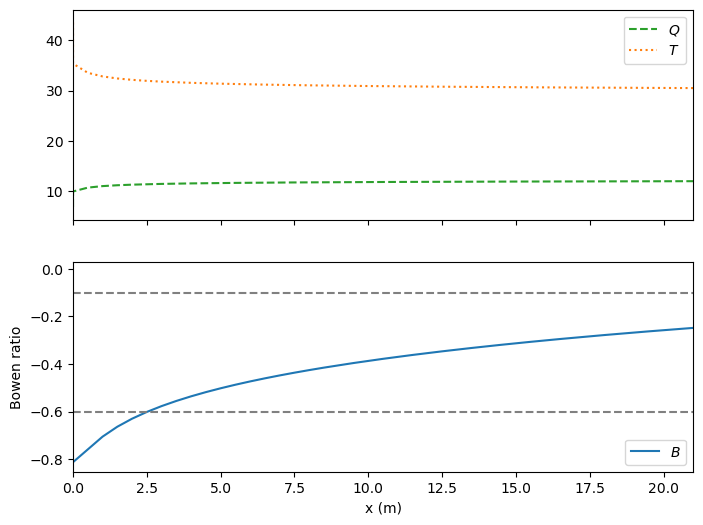

In [10]:
level = 2


fig, axes = plt.subplots( 2, 1, figsize = (8, 6 ), sharex = True)
ax = axes[0]
xx =  np.concatenate([-np.flip(x),x])
Q = np.concatenate([ Q_up[level]*np.ones_like(x), Q_uniform[:, level]])
T = np.concatenate([ T_up[level]*np.ones_like(x), T_uniform[:, level]])

ax.plot(xx[1:], (Q[1:]),  ls = '--', c =  'C2',  label = "$Q$")
ax.plot(xx[1:], (T[1:]),  ls = ':', c =  'C1',  label = "$T$")
ax.set_xlim(0, 21)


ax.legend()

ax = axes[1]
x = p.x

ax.plot(x, (H_uniform_Wm2[:, level])/LE_uniform_Wm2[:, level], label = "$B$")
plt.xlabel("x (m)")
plt.ylabel("Bowen ratio")
ax.axhline(-0.1, ls = '--', c = 'grey')
ax.axhline(-0.6, ls = '--', c = 'grey')

plt.legend()
# Sensible heat flux needs to move to 0 faster than LE moves to LE_c? 

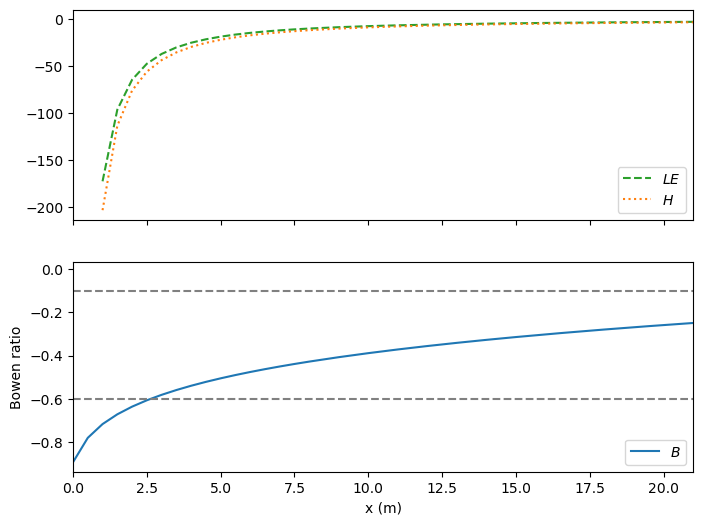

In [11]:
level = 0
fig, axes = plt.subplots( 2, 1, figsize = (8, 6 ), sharex = True)
ax = axes[0]

xx = np.concatenate([-np.flip(x),x])
FluxTotal_ = np.concatenate([FluxTotal_upwind, FluxTotal[:, level]])

LE_Wm2 = np.concatenate([ LE_upwind_Wm2[level]*np.ones_like(x), LE_uniform_Wm2[:, level]])
H_Wm2 = np.concatenate([ H_upwind_Wm2[level]*np.ones_like(x), H_uniform_Wm2[:, level]])

ax.plot(p.x[2:], np.diff(LE_uniform_Wm2[1:,level]),  ls = '--', c =  'C2',  label = "$LE$")
ax.plot(p.x[2:], - np.diff(H_uniform_Wm2[1:, level]),  ls = ':', c =  'C1',  label = "$H$")
ax.set_xlim(0, 21)

# ax.set_yscale('log')
ax.legend()

ax = axes[1]
x = p.x

ax.plot(x, (H_uniform_Wm2[:, level])/LE_uniform_Wm2[:, level], label = "$B$")
plt.xlabel("x (m)")
plt.ylabel("Bowen ratio")
ax.axhline(-0.1, ls = '--', c = 'grey')
ax.axhline(-0.6, ls = '--', c = 'grey')

plt.legend()
# Sensible heat flux needs to move to 0 faster than LE moves to LE_c? 

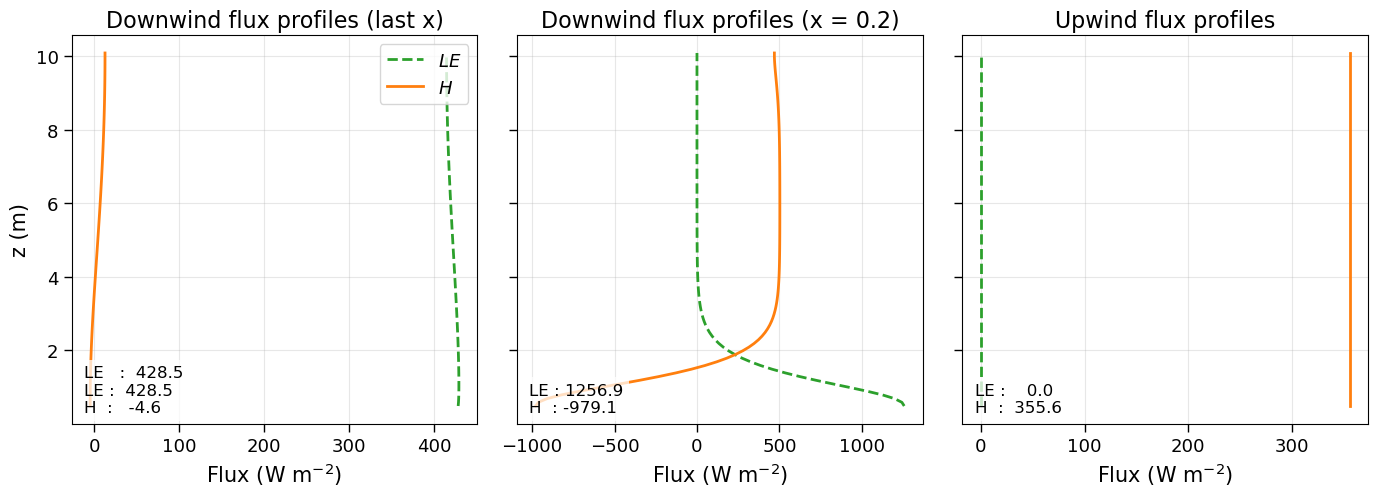

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- gradient-based flux checks (using two-point logs) ----------------
# Downwind (last x)
le_last = p.ustar_c * p.k * (Q_uniform[-1, 1] - Q_uniform[-1, 0]) / np.log(p.z[0] / p.z[1]) * Lv_g
h_last  = p.ustar_c * p.k * (T_uniform[-1, 1] - T_uniform[-1, 0]) / np.log(p.z[0] / p.z[1]) * rho_air * cp_air

# Downwind (near-upstream, x index 1)
le_x1 = p.ustar_c * p.k * (Q_uniform[1, 1] - Q_uniform[1, 0]) / np.log(p.z[0] / p.z[1]) * Lv_g
h_x1  = p.ustar_c * p.k * (T_uniform[1, 1] - T_uniform[1, 0]) / np.log(p.z[0] / p.z[1]) * rho_air * cp_air

# Upwind
le_up = p.ustar_f * p.k * (Q_up[1] - Q_up[2]) / np.log(p.z[2] / p.z[1]) * Lv_g
h_up  = p.ustar_f * p.k * (T_up[1] - T_up[0]) / np.log(p.z[0] / p.z[1]) * rho_air * cp_air

# ---------------- figure with 3 subplots (larger fonts, consistent styles across subplots) ----------------
plt.rcParams.update({
    "font.size": 14,                # base font size
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "legend.fontsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})

fig, axes = plt.subplots(1, 3, figsize=(14, 5.2), sharey=True)

# Common styles (do not change between subplots)
style_LE = dict(color='C2', linestyle='--', linewidth=2.0, label='$LE$')
style_H  = dict(color='C1', linestyle='-',  linewidth=2.0, label='$H$')

# Panel 1: Downwind (last x) vertical profiles
ax = axes[0]
ax.plot(LE_uniform_Wm2[-1, :], p.z, **style_LE)
ax.plot(H_uniform_Wm2[-1, :],  p.z, **style_H)
ax.set_title("Downwind flux profiles (last x)")
ax.set_xlabel("Flux (W m$^{-2}$)")
ax.set_ylabel("z (m)")
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
ax.tick_params(length=6, width=1)

txt1 = (f"LE   : {le_last:6.1f}\n"
        f"LE : {le_last:6.1f}\n"
        f"H  : {h_last:6.1f}")
ax.text(0.03, 0.03, txt1, transform=ax.transAxes, fontsize=12,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))

# Panel 2: Downwind (x=1) vertical profiles
ax = axes[1]
ax.plot(LE_uniform_Wm2[1, :], p.z, **style_LE)
ax.plot(H_uniform_Wm2[1, :],  p.z, **style_H)
ax.set_title("Downwind flux profiles (x = 0.2)")
ax.set_xlabel("Flux (W m$^{-2}$)")
ax.grid(True, alpha=0.3)
# ax.legend(loc='best')
ax.tick_params(length=6, width=1)

txt2 = (f"LE : {le_x1:6.1f}\n"
        f"H  : {h_x1:6.1f}")
ax.text(0.03, 0.03, txt2, transform=ax.transAxes, fontsize=12,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))

# Panel 3: Upwind vertical profiles
ax = axes[2]
ax.plot(LE_upwind_Wm2, p.z, **style_LE)
ax.plot(H_upwind_Wm2,  p.z, **style_H)
ax.set_title("Upwind flux profiles")
ax.set_xlabel("Flux (W m$^{-2}$)")
ax.grid(True, alpha=0.3)
# ax.legend(loc='best')
ax.tick_params(length=6, width=1)

txt3 = (f"LE : {le_up:6.1f}\n"
        f"H  : {h_up:6.1f}")
ax.text(0.03, 0.03, txt3, transform=ax.transAxes, fontsize=12,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))

plt.tight_layout()
plt.show()



In [13]:
# Upwind checks

H_wall_Wm2  =  p.ustar_f * p.k * (p.T_sf - p.T_a) / np.log(p.Hmax / p.z[0]) * rho_air *cp_air

print("H_f (Params):       ", p.H_f)
print("H_wall:              {0:.2f}".format( H_wall_Wm2) ) 


# Downwind checks
# Lv_g = 2430.0  # J g^-1
Fq_wall_gm2s = p.ustar_c * p.k * (p.Q_c - p.Q_a) / np.log(p.Hmax / p.z[0])
LE_wall_Wm2  = Fq_wall_gm2s * Lv_g

print("\nLE_c (Params):      ", p.LE_c)
print("LE_wall:             {0:.2f} ".format(LE_wall_Wm2))  


H_f (Params):        355.64
H_wall:              355.64

LE_c (Params):       426.768
LE_wall:             426.77 


\begin{aligned}
\mathrm{SW}\,(1-\alpha_f) + \varepsilon_a \,\sigma_{SB}\, T_a^{4}
  - \varepsilon_f \,\sigma_{SB}\, T_{sf}^{4} &= R_{n,f}, \\
\mathrm{SW}\,(1-\alpha_c) + \varepsilon_a \,\sigma_{SB}\, T_a^{4}
  - \varepsilon_c \,\sigma_{SB}\, T_{sc}^{4} &= R_{n,c}, \\
T_{sf} - T_a &= \frac{1}{k\,u_{*f}}\,
  \frac{H_f}{\rho\,c_p}\,
  \ln\!\left(\frac{z_h}{z_\ell}\right), \\
T_{sc} - T_a &= \frac{1}{k\,u_{*c}}\,
  \frac{H_c}{\rho\,c_p}\,
  \ln\!\left(\frac{z_h}{z_\ell}\right), \\
Q_c - Q_a &= \frac{1}{k\,u_{*c}}\,
  \frac{\mathrm{LE}_c}{L_v}\,
  \ln\!\left(\frac{z_h}{z_\ell}\right), \\
R_{n,c} - G &= \mathrm{LE}_c + H_c .
\end{aligned}

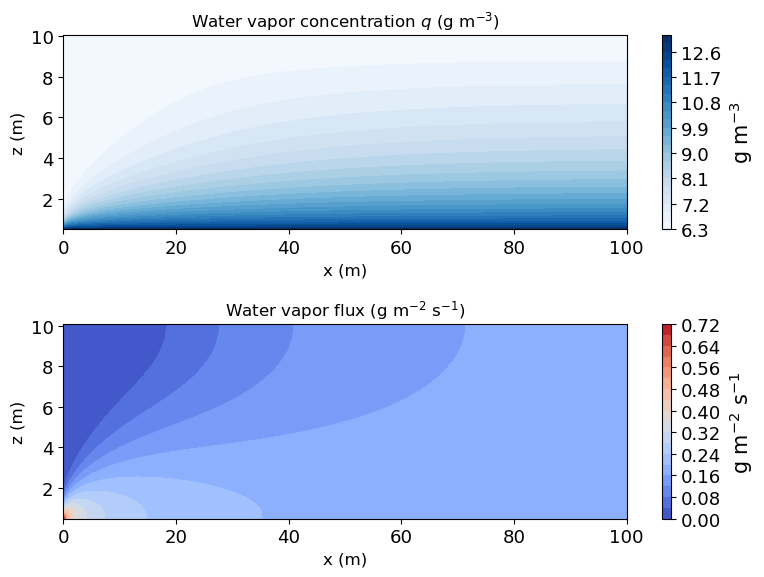

In [14]:
z = p.z
x = p.x

# Plot water vapor concentration and vertical flux
plt.figure(figsize = (8, 6))

plt.subplot(2, 1, 1)
nz = Q_uniform.shape[1]
plt.contourf(x, z[:nz], (Q_uniform.T), 25, cmap='Blues',  vmax = p.Q_c, vmin =p.Q_a)
plt.colorbar(label='g m$^{-3}$')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor concentration $q$ (g m$^{-3}$)', fontsize=12)

plt.subplot(2, 1, 2)
plt.contourf(x, z[:nz], FluxQ_uniform.T.round(4),  20, cmap='coolwarm', vmin = 0, vmax = FluxQ_uniform.max())
plt.colorbar(label='g m$^{-2}$ s$^{-1}$') 
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor flux (g m$^{-2}$ s$^{-1}$)', fontsize=12)
plt.tight_layout()



In [19]:

level = 1
# rough estimate at level height z:
z_eff = z[level] - p.h_c*2/3
lm    = p.k * z_eff  
K     = lm * ustar_c
U = (p.ustar_f / p.k) * np.log(z / p.zom_c) 
Lrec  = U[level] * z_eff / (p.k * ustar_c)   

In [20]:
Q_uniform.shape, p.z.shape

((201, 97), (97,))

In [21]:
2//p.dx

4.0

### Appendix

In [ ]:
# density depends on air temperature
import numpy as np

# --- constants ---
cp  = 1005.0          # J kg^-1 K^-1  (specific heat at constant pressure)
R_d = 287.05          # J kg^-1 K^-1  (gas constant for dry air)
p_Pa = 101325.0       # Pa (set your measured station pressure if available)

def air_density(T_K, p_Pa=101325.0, q_kgkg=None):
    """
    Air density [kg m^-3] from temperature (K), pressure (Pa), and optional specific humidity q (kg/kg).
    Uses virtual temperature: T_v = T*(1 + 0.61 q) if q is provided.
    """
    if q_kgkg is not None:
        T_v = T_K * (1.0 + 0.61*q_kgkg)
    else:
        T_v = T_K
    return p_Pa / (R_d * T_v)

# If you already have ambient humidity as Q_a in g/kg, use it for moist-air density.
# Otherwise we'll compute a dry-air density.
try:
    q_a = Q_a / 1000.0   # g/kg -> kg/kg
except NameError:
    q_a = None

T_a = 30
rho = air_density(T_a, p_Pa=p_Pa, q_kgkg=q_a)

# --- your original variables ---
zo = zom_f
ustar_f = 0.15
ustar_c = 0.15

# stability-neutral bulk transfer (ensure z_h > zo)
L = np.log(z_h / zo)      # dimensionless

# Use rho*cp instead of 1005*1.2
T_sc = T_a + (H_c/(rho*cp)) * (1.0/(k*ustar_c)) * L
print(T_sc - 273.15)

T_sf = T_a + (H_f/(rho*cp)) * (1.0/(k*ustar_f)) * L
print(T_sf - 273.15)

print(T_sf - T_sc)


### Appendix B - solve all BCs

In [25]:

# print (ustar_c)
 
# what is h? what is d? 
from sutton import Params, saturation_vapor_pressure, vapor_concentration_RH
import numpy as np

def get_params(fallow_fraction = 0.5, fallow_length = 1000, 
               T_sc = 30, T_sf = 50, T_a = 18, 
               Q_a = 5, Q_c = 20, RH_c = 60,
               h = 0.04, zom_f = 0.14/100, zom_c = 0.14/100,
               SW_in = 400, e_f = 0.95, e_c = 0.95, e_a = .8,
               ustar_f = 0.15, ustar_c = ustar_c,
               alpha_c = 0.22, alpha_f = 0.22,
               lm_option = 'kz', adj_grid = 0):
    p = Params(fallow_length=fallow_length, fallow_fraction=fallow_fraction,
               T_sc=T_sc, T_sf=T_sf, T_a=T_a, RH_c=RH_c, RH_f=RH_c, RH_a=RH_c,
               h=h, zom_f=zom_f, zom_c=zom_c, SW_in=SW_in, e_f=e_f, e_c=e_c, e_a=e_a,
               alpha_c=alpha_c, alpha_f=alpha_f, lm_option=lm_option, Hmax=10, dx=0.1, dz=0.001, Lx=30)
    d = p.to_dict()
    # Override Q values if provided explicitly
    d['Q_a'] = Q_a
    d['Q_c'] = Q_c
    d['H_f'] = 8.5*4.184e-3/1e-4  # from earlier cell

    d['adj_grid'] = adj_grid
    # Legacy counts
    z = np.arange(d['zmin'] + d['dz'], d['zmax'] + d['dz'], d['dz'])

    x = np.arange(d['xmin'], d['xmax'] + d['dx'], d['dx'])
    d['nz'] = len(z)
    d['nx'] = len(x)
    return d

d = get_params()


# downwind humidity is 60%
G  = 30
Rn_f = H_f + G
Rn_c = H_f + G

SW = 500
T_a = 30 + 273.15
Q_a = 6

epsilon_a = 0.95
epsilon_f = 0.8
epsilon_c = 0.95

params = get_params(h = 2.3, SW_in = SW, 
               e_f = epsilon_f, e_c = epsilon_c, e_a = epsilon_a,            
               lm_option = 'kz', adj_grid = 0)

z_h = params['Hmax']

zom_f = params['zom_f']
zom_c = params['zom_c']
zoh_f = params['zom_f']/5
zoh_c = params['zom_c']/5

k = params['k']
ustar_f = params['ustar_f']
ustar_c = params['ustar_c']

z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], params['dz'])

# Define symbols
sigma_sb = 5.67*1e-8

Q_f = Q_a
Q_c =  Q_f + 8

T_sf, T_sc, alpha_f, alpha_c, H_c, LE_c = symbols('T_sf T_sc alpha_f alpha_c H_c  LE_c')

level = 0

eq1 = Eq(SW*(1-alpha_f) + epsilon_a*sigma_sb*T_a**4 - epsilon_f*sigma_sb*T_sf**4, Rn_f )

eq2 = Eq(SW*(1-alpha_c) + epsilon_a*sigma_sb*T_a**4 - epsilon_c*sigma_sb*T_sc**4, Rn_c )

eq3 = Eq(T_sf - T_a, 1/(k*ustar_f)*H_f/((1005*1.2))*np.log(z_h/(z[level])))

eq4 = Eq(T_sc - T_a, 1/(k*ustar_c)*H_c/((1005*1.2))*np.log(z_h/(z[level])))

eq5 = Eq(Q_c - Q_a, 1/(k*ustar_c)*LE_c/2260*np.log(z_h/(z[level])))

eq6 = Eq(Rn_c - G, LE_c +  H_c)

# Solve the system of equations
solution = solve((eq1, eq2, eq3,  eq4, eq5, eq6), 
                 (T_sf, T_sc, alpha_f, alpha_c, LE_c,  H_c ))

T_sf, T_sc, alpha_f, alpha_c, LE_c,  H_c = solution[0]

T_a = T_a - 273.15
T_sf = T_sf - 273.15
T_sc = T_sc - 273.15

T_sf,  T_sc

(61.9957795839125, 47.0040714578761)

In [24]:
# def uniform_Q(params):
#     """
#     The function computes an implicit solution for water vapor concentration and
#     flux in a turbulent boundary layer.
    
#     - Uses an implicit finite-difference method for solving the transport equation.
#     - Implements mixing length theory to define eddy diffusivity.
#     - Marches along the x-direction to iteratively solve for the concentration field.

#     Q_f, Q_c, and Q_a are all absolute humidity (g/m3)
#     """
#     nx = params['nx']
#     nz = params['nz']    
#     dx = params['dx']    
#     dz = params['dz']  
#     zmax = params['zmax']      
#     k = params['k']          
    
#     ustar_f = params['ustar_f']
#     zom_f = params['zom_f']     
#     ustar_c = params['ustar_c']
#     zom_c = params['zom_c']  
    
#     Q_f = params['Q_f'] 
#     Q_c = params['Q_c']
#     Q_a = params['Q_a']
    
#     h = params['h']
#     lm_option = params['lm_option']


#     z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], 
#                   params['dz'])    

#     FQ_f = ustar_f*k*(Q_f - Q_a)/np.log(zmax/zom_f)  # g m⁻² s⁻¹
#     Qup = Q_f - FQ_f/(k*ustar_f)*np.log(z/zom_f)     # g m⁻³
    
#     FQ_c = ustar_c*k*(Q_c - Q_a)/np.log(zmax/zom_c)  # g m⁻² s⁻¹
#     Qdown = Q_c - FQ_c/(k*ustar_c)*np.log(z/zom_c)   # g m⁻³
    
#     U = (ustar_c / k) * np.log(z / zom_c) 
    
#     lm = get_lm(k, h, z, lm_option)    
    
#     # Setup coefficients for the implicit scheme
#     A = lm * ustar_c
#     B = 1.0 / U
#     C = our_central_difference(A, dz)

#     # Upwind wv concentrations and fluxes
#     Q1 = Qup
#     Q_uniform = np.zeros((nx , nz))
#     Q_uniform[0, :] = Q1
#     FluxQ_uniform = np.zeros((nx , nz))

#     # Begin downwind calculations by marching along x
#     for i in range(nx):
#         Q2, Fq = integrate_H2O_implicit(nx, nz, dx, dz, A, B, C, Q1, Qdown[0], Q_a)
#         Q_uniform[i, :] = Q2
#         FluxQ_uniform[i, :] = Fq
#         Q1 = Q2
        
#     return Q_uniform, FluxQ_uniform # g m⁻³,  g m⁻² s⁻¹ (mass flux)

# def uniform_T(params):
#     """
#     The function solves an implicit equation for temperature transport in a turbulent boundary layer.
    
#     - Uses an implicit finite-difference method to solve the advection-diffusion equation.
#     - Mixing length theory is applied to define eddy diffusivity.
#     - Marches along the x-direction to iteratively compute the temperature field.
    
#     """
#     nx = params['nx']
#     nz = params['nz']    
#     dx = params['dx']        
#     dz = params['dz']        
#     k = params['k']              
#     zmax = params['zmax']
    
#     ustar_f = params['ustar_f']
#     zom_f = params['zom_f']    
#     ustar_c = params['ustar_c']
#     zom_c = params['zom_c']  
    
#     T_sf = params['T_sf']    
#     T_sc = params['T_sc']
#     T_a = params['T_a']
#     h = params['h']    
    
#     lm_option = params['lm_option']

    
#     z = np.arange(params['zmin'] + params['dz'], 
#                   params['zmax'] + params['dz'], params['dz'])
    
#     wT = - (T_a - T_sf)*k*ustar_f/np.log(zmax/zom_f)      # K m/s 
#     Tup = T_sf - wT/(k*ustar_f)*np.log(z/zom_f)

#     wT_down = -(T_a - T_sc)*k*ustar_c/np.log(zmax/zom_c)  # K m/s    
#     Tdown = T_sc - wT_down/(k*ustar_c)*np.log(z/zom_c)

#     U = (ustar_c / k) * np.log(z / zom_c)    
    
#     # Setup coefficients for the implicit scheme
#     lm = get_lm(k, h, z, lm_option)       
#     A = lm * ustar_c
#     B = 1.0 / U
#     C = our_central_difference(A, dz)

#      # Upwind wv concentrations and fluxes
#     T1 = Tup
#     T_uniform = np.zeros((nx , nz))
#     T_uniform[0, :] = T1
#     FluxT_uniform = np.zeros((nx , nz))

#     for i in range(nx):
        
#         T2, FT = integrate_T_implicit(nx, nz, dx, dz, A, B, C, T1, Tdown[0], T_a)
#         T_uniform[i, :] = T2
#         FluxT_uniform[i, :] = FT
#         T1 = T2
    
#     return T_uniform, FluxT_uniform